# Notebook Logger Example

This notebook demonstrates logging notebook runs to LabArchives using `NotebookLogger`.

**Steps:**
1. Run Cell 1 — authenticate (a clickable link appears; click it and log in)
2. Run Cell 2 — do some computation and plotting
3. Run Cell 3 — open the save UI, enter tags, click **Save to LabArchives**

**Note:** If you iterate on the `notebook_logger.py` code and re-import it, you can pass the existing `user` object back to the constructor to skip the authentication step.

In [2]:
# Cell 1: Authenticate
import notebook_logger
import importlib

importlib.reload(notebook_logger)

# Reuse existing user if already authenticated in this session
try:
    user = logger.user
except NameError:
    user = None

# Replace with your LabArchives notebook name
logger = notebook_logger.NotebookLogger(notebook_name="DSST Test Notebook", user=user)

Using existing authentication for: licc@nih.gov


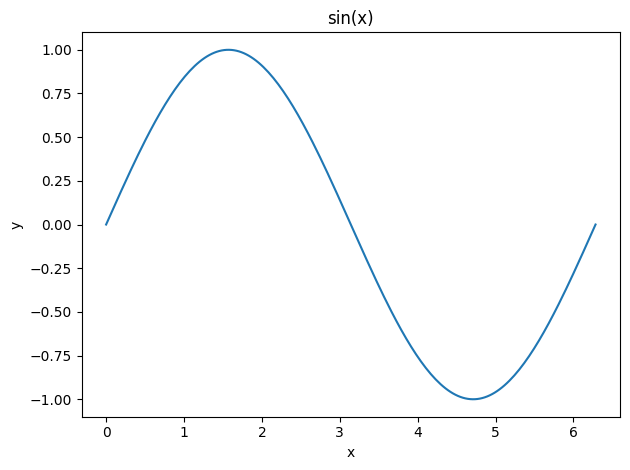

Tracking file for LabArchives: results.csv


np.float64(2.220446049250313e-16)

In [3]:
# Cell 2: Computation + plot + file output
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title("sin(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()  # Figure is closed here, but logger captures it automatically!

# 1. Save some data to a file
df = pd.DataFrame({"x": x, "y": y})
df.to_csv("results.csv", index=False)

# 2. Tell the logger to track this file
logger.track_file("results.csv")

# The last expression becomes the logged result
np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.trapz(y, x)

In [4]:
# Cell 3: Save UI
# Enter tags (comma-separated) and click "Save to LabArchives"
logger.show_ui()